In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from sometria.catalog import (
    MotionViewSpec,
    build_motion_view,
    create_pretrain_split,
    load_annotations,
    load_catalog,
    load_label_vocabulary,
    load_splits,
    normalization_path,
)
from sometria.preprocess import ImportConfig, import_opensim_csv_dataset
from sometria.babel import (
    import_babel_splits,
    import_babel_annotations,
    import_babel_action_vocabulary,
)
from sometria.normalization import save_feature_normalization
from sometria.representation import Representation, _load_human_definition


In [2]:
RAW_AMASS = Path("/home/z1ko/datasets/sometria/amass")
RAW_BABEL = Path("/home/z1ko/datasets/sometria/babel")
OUT = Path("../data/processed")

# the representation carries its own name, so the stats path and the catalog column
# cannot drift from the encoding that actually produced the tensors
HUMAN = _load_human_definition("/home/z1ko/develop/sometria/config/human.yaml")
REPRESENTATION = Representation.from_human(HUMAN)
NORMALIZATION_NAME = "pretrain_v1_train_clean"
# catalog owns the layout; nothing outside it should spell out stats/<representation>/<name>.pt
NORMALIZATION_PATH = normalization_path(OUT, REPRESENTATION.name, NORMALIZATION_NAME)
print(REPRESENTATION)


Representation('opensim_sincos_log_vel_acc_tau_v2', 43 dofs, 5 channels)


In [ ]:
catalog = import_opensim_csv_dataset(
    config=ImportConfig(
        source_dataset="AMASS",
        input_root=RAW_AMASS,
        output_root=OUT,
        pattern="**/*.csv"
    ),
    human=HUMAN,
    representation=REPRESENTATION,
)

# split membership and the labels themselves are separate tables on purpose: a sample can
# belong to a split whether or not BABEL published labels for it (test is exactly that case)
babel_splits = import_babel_splits(
    babel_root=RAW_BABEL,
    output_root=OUT
)

babel_annotations = import_babel_annotations(
    babel_root=RAW_BABEL,
    output_root=OUT
)

# the 150-class benchmark vocabulary: which act_cat labels downstream tasks are allowed to score
babel_vocabulary = import_babel_action_vocabulary(
    babel_root=RAW_BABEL,
    output_root=OUT
)

pretrain = create_pretrain_split(output_root=OUT)

print(f"{len(catalog):,} samples | {len(babel_annotations):,} annotations | {len(babel_vocabulary)} action classes")
catalog.head()


## Normalization


In [ ]:
train_samples = build_motion_view(
    OUT,
    MotionViewSpec(
        split_set="pretrain_v1",
        split="train",
        source_datasets=("AMASS",),
        exclude_broken=True,
    )
)

stats_path = save_feature_normalization(
    output_root=OUT,
    samples=train_samples,
    name=NORMALIZATION_NAME,
    representation=REPRESENTATION,
    split_set="pretrain_v1",
    split="train",
)

stats_path


## Catalog sanity checks

These cells inspect the final AMASS motion catalog and BABEL-derived split tables. They are meant to answer: what was imported, what is labelled, what is clean, and what will each training view actually see?

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch as t

catalog = load_catalog(OUT)
splits = load_splits(OUT)

babel_ids = (
    splits
    .filter(pl.col("split_set") == "babel_official")
    .select("sample_id")
    .unique()
    .get_column("sample_id")
    .to_list()
)

catalog = catalog.with_columns(
    pl.col("sample_id").is_in(babel_ids).alias("has_babel_split")
)

print(f"{len(catalog):,} motion samples")
print(f"{catalog['duration'].sum() / 3600:.1f} motion hours")
print(f"{catalog['source_subset'].n_unique()} AMASS subsets")
if {"n_dofs", "n_features"} <= set(catalog.columns):
    print(f"feature shape: {catalog['n_dofs'][0]} dofs x {catalog['n_features'][0]} features")
else:
    print("feature shape: rerun the import cell to populate n_dofs/n_features")
print(f"{catalog['has_babel_split'].sum():,} samples matched to BABEL official splits")
if NORMALIZATION_PATH.exists():
    stats = t.load(NORMALIZATION_PATH, weights_only=True)
    print(
        f"normalization: {NORMALIZATION_PATH} "
        f"({stats['n_samples']:,} samples, {stats['n_frames']:,} frames)"
    )
else:
    print(f"normalization: missing ({NORMALIZATION_PATH})")

catalog.head(3)


17,453 motion samples
40.6 motion hours
26 AMASS subsets
feature shape: 43 dofs x 5 features
10,487 samples matched to BABEL official splits
normalization: ../data/processed/stats/opensim_sincos_log_vel_acc_tau_v2/pretrain_v1_train_clean.pt (12,722 samples, 6,050,474 frames)


sample_id,source_dataset,source_subset,source_path,motion_path,representation,metadata,hz,original_hz,n_frames,duration,tau_rate,tau_absmax,nonfinite,broken,n_dofs,n_features,has_babel_split
str,str,str,str,str,str,struct[2],f64,f64,i64,f64,f64,f64,bool,bool,i64,i64,bool
"""AMASS:KIT/423/downstairs03_sta…","""AMASS""","""KIT""","""KIT/423/downstairs03_stageii.c…","""motions/amass/4c7fdfc4e5589ea1…","""opensim_sincos_log_vel_acc_tau…","{1.723452,65.34628}",60.0,100.200401,338,5.633333,18708.879498,1029.05227,false,false,43,5,true
"""AMASS:SFU/0018/0018_DanceTurns…","""AMASS""","""SFU""","""SFU/0018/0018_DanceTurns002_st…","""motions/amass/9bb84830913033d3…","""opensim_sincos_log_vel_acc_tau…","{1.62789,58.300602}",60.0,120.048019,934,15.566667,129453.582293,2384.527955,false,false,43,5,true
"""AMASS:KIT/6/LeftTurn10_1_stage…","""AMASS""","""KIT""","""KIT/6/LeftTurn10_1_stageii.csv""","""motions/amass/8b7af6679029b302…","""opensim_sincos_log_vel_acc_tau…","{1.746267,67.087863}",60.0,100.200401,300,5.0,12675.13898,903.81568,false,false,43,5,true


### Coverage overview

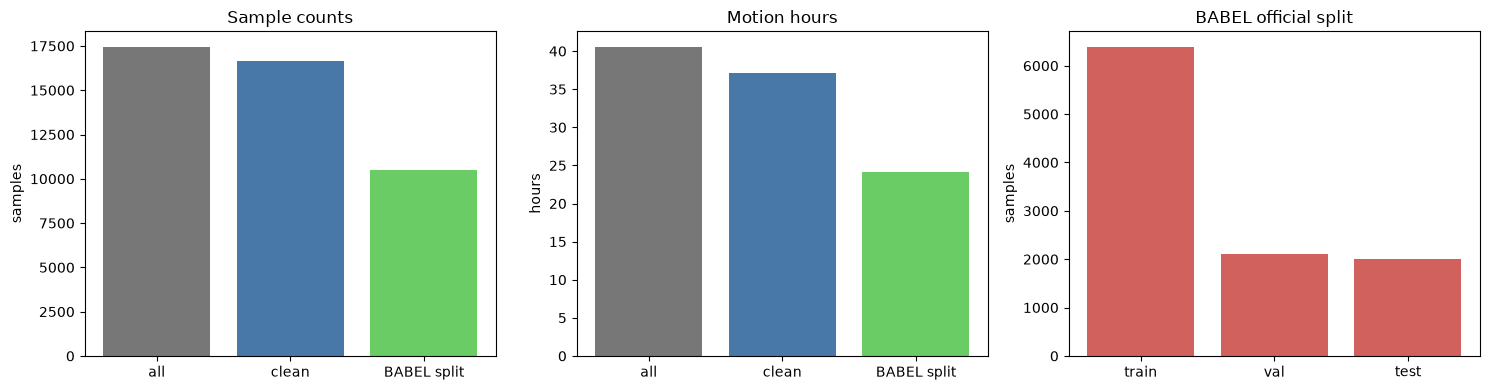

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

clean = (~catalog["broken"]).to_numpy()
has_babel = catalog["has_babel_split"].to_numpy()

ax[0].bar(
    ["all", "clean", "BABEL split"],
    [len(catalog), int(clean.sum()), int(has_babel.sum())],
    color=["#777777", "#4878a8", "#6acc64"],
)
ax[0].set(title="Sample counts", ylabel="samples")

hours = [
    catalog["duration"].sum() / 3600,
    catalog.filter(~pl.col("broken"))["duration"].sum() / 3600,
    catalog.filter(pl.col("has_babel_split"))["duration"].sum() / 3600,
]
ax[1].bar(["all", "clean", "BABEL split"], hours, color=["#777777", "#4878a8", "#6acc64"])
ax[1].set(title="Motion hours", ylabel="hours")

split_order = {"train": 0, "val": 1, "test": 2}
split_counts = (
    splits
    .filter(pl.col("split_set") == "babel_official")
    .group_by("split")
    .len()
    .with_columns(pl.col("split").replace(split_order).cast(pl.Int64).alias("order"))
    .sort("order")
)
ax[2].bar(split_counts["split"], split_counts["len"], color="#d1615d")
ax[2].set(title="BABEL official split", ylabel="samples")

fig.tight_layout()

### Per-dataset summary

In [5]:
dataset_summary = (
    catalog
    .group_by("source_subset")
    .agg(
        pl.len().alias("samples"),
        (~pl.col("broken")).sum().alias("clean_samples"),
        pl.col("has_babel_split").sum().alias("babel_samples"),
        (pl.col("duration").sum() / 3600).alias("motion_hours"),
        (pl.when(~pl.col("broken")).then(pl.col("duration")).otherwise(0).sum() / 3600).alias("clean_motion_hours"),
        pl.col("broken").sum().alias("broken_samples"),
    )
    .with_columns(
        (100 * pl.col("babel_samples") / pl.col("samples")).alias("babel_pct"),
        (100 * pl.col("broken_samples") / pl.col("samples")).alias("broken_pct"),
    )
    .sort("motion_hours", descending=True)
)

print(dataset_summary.with_columns(
    pl.col("motion_hours").round(2),
    pl.col("clean_motion_hours").round(2),
    pl.col("babel_pct").round(1),
    pl.col("broken_pct").round(1),
))

shape: (26, 9)
┌────────────┬─────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ source_sub ┆ samples ┆ clean_sam ┆ babel_sam ┆ … ┆ clean_mot ┆ broken_sa ┆ babel_pct ┆ broken_pc │
│ set        ┆ ---     ┆ ples      ┆ ples      ┆   ┆ ion_hours ┆ mples     ┆ ---       ┆ t         │
│ ---        ┆ u32     ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ ---       │
│ str        ┆         ┆ u32       ┆ u32       ┆   ┆ f64       ┆ u32       ┆           ┆ f64       │
╞════════════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ KIT        ┆ 4147    ┆ 4127      ┆ 3201      ┆ … ┆ 8.27      ┆ 20        ┆ 77.2      ┆ 0.5       │
│ BMLrub     ┆ 2992    ┆ 2978      ┆ 2674      ┆ … ┆ 6.04      ┆ 14        ┆ 89.4      ┆ 0.5       │
│ CMU        ┆ 1878    ┆ 1465      ┆ 1590      ┆ … ┆ 4.16      ┆ 413       ┆ 84.7      ┆ 22.0      │
│ GRAB       ┆ 1338    ┆ 1331      ┆ 0         ┆ … ┆ 3.54      ┆ 7         ┆

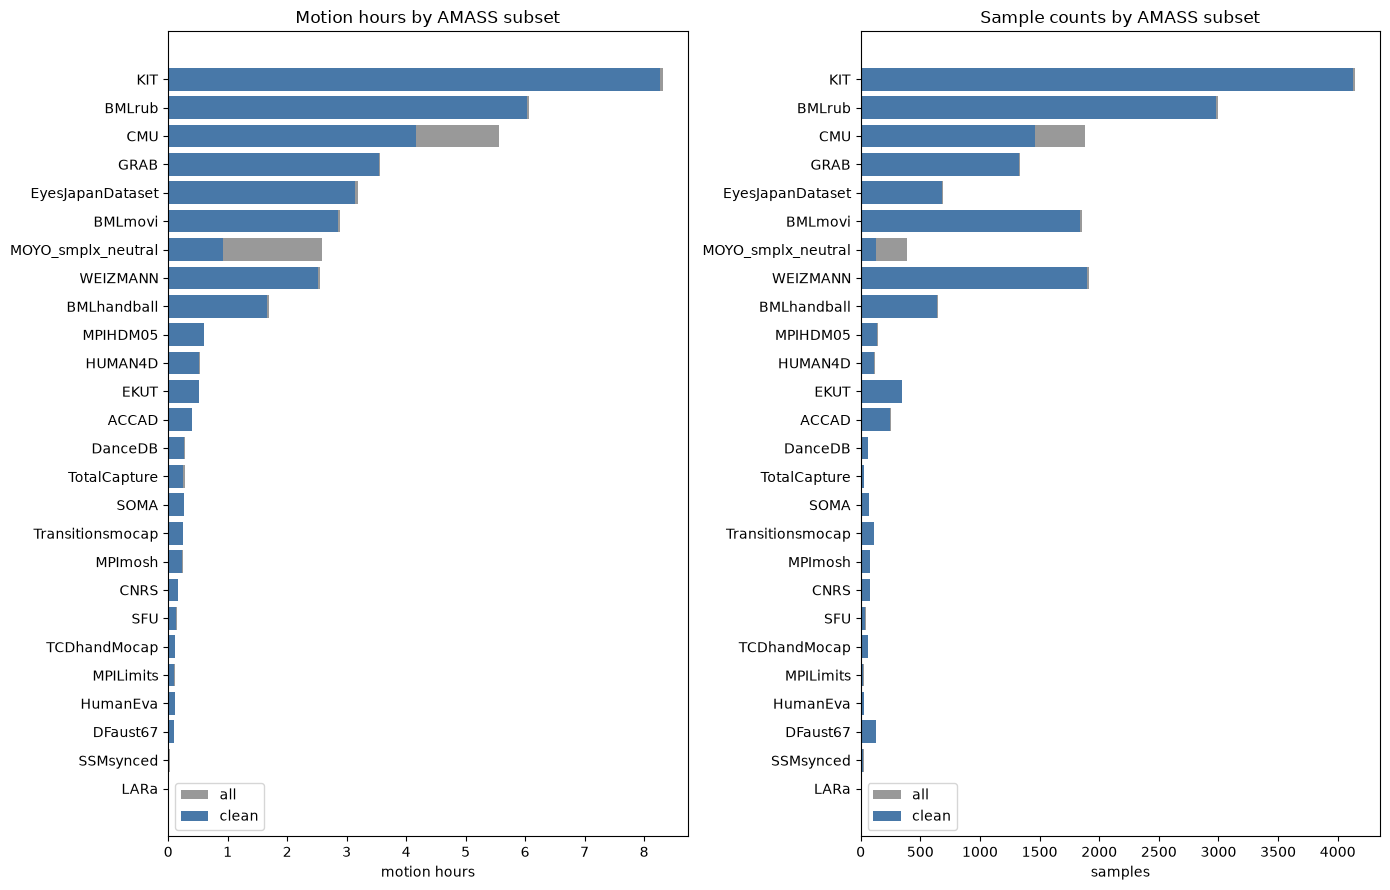

In [6]:
top_hours = dataset_summary.head(30).sort("motion_hours")

fig, ax = plt.subplots(1, 2, figsize=(14, 9))
y = np.arange(len(top_hours))

ax[0].barh(y, top_hours["motion_hours"], color="#999999", label="all")
ax[0].barh(y, top_hours["clean_motion_hours"], color="#4878a8", label="clean")
ax[0].set_yticks(y, top_hours["source_subset"])
ax[0].set_xlabel("motion hours")
ax[0].set_title("Motion hours by AMASS subset")
ax[0].legend()

ax[1].barh(y, top_hours["samples"], color="#999999", label="all")
ax[1].barh(y, top_hours["clean_samples"], color="#4878a8", label="clean")
ax[1].set_yticks(y, top_hours["source_subset"])
ax[1].set_xlabel("samples")
ax[1].set_title("Sample counts by AMASS subset")
ax[1].legend()

fig.tight_layout()

### BABEL coverage by AMASS subset

In [ ]:
coverage = (
    catalog
    .group_by("source_subset")
    .agg(
        pl.len().alias("n"),
        pl.col("has_babel_split").sum().alias("babel"),
        pl.col("broken").sum().alias("broken"),
        (pl.col("duration").sum() / 3600).alias("hours"),
    )
    .with_columns(
        (100 * pl.col("babel") / pl.col("n")).alias("babel_pct"),
        (100 * pl.col("broken") / pl.col("n")).alias("broken_pct"),
    )
    .sort("n", descending=True)
)

top = coverage.head(30).sort("babel_pct")

fig, ax = plt.subplots(figsize=(8, 9))
y = np.arange(len(top))

ax.barh(y, top["babel_pct"], color="#6acc64")
ax.set_yticks(y, top["source_subset"])
ax.set_xlabel("% samples with BABEL split")
ax.set_title("BABEL coverage by AMASS subset")
ax.set_xlim(0, 100)

fig.tight_layout()

### Labelled vs unlabelled duration

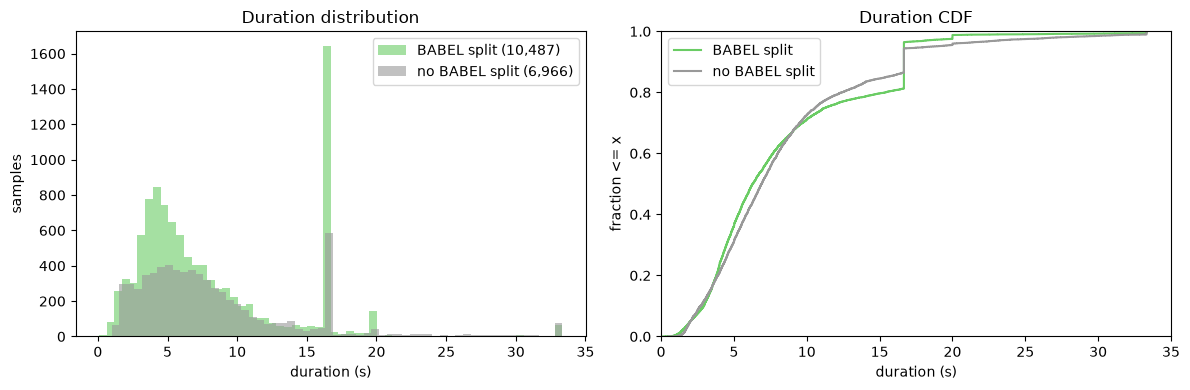

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for label, filt, color in [
    ("BABEL split", pl.col("has_babel_split"), "#6acc64"),
    ("no BABEL split", ~pl.col("has_babel_split"), "#999999"),
]:
    x = catalog.filter(filt)["duration"].to_numpy()
    ax[0].hist(x, bins=60, alpha=0.6, label=f"{label} ({len(x):,})", color=color)
    ax[1].ecdf(x, label=label, color=color)

ax[0].set(xlabel="duration (s)", ylabel="samples", title="Duration distribution")
ax[1].set(xlabel="duration (s)", ylabel="fraction <= x", title="Duration CDF", xlim=(0, 35))
ax[0].legend()
ax[1].legend()

fig.tight_layout()

### Torque quality

`measure_quality` runs on the raw OpenSim channels before `Representation.encode`, so `tau_rate` and `tau_absmax` below stay in physical units, unaffected by the signed-log transform. That is deliberate: discontinuity detection belongs in real torque units, not compressed ones.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

clean_catalog = catalog.filter(~pl.col("broken"))
broken_catalog = catalog.filter(pl.col("broken"))

ax[0].hist(np.log10(clean_catalog["tau_rate"].to_numpy().clip(1)), bins=60, alpha=0.8, color="#4878a8", label="clean")
ax[0].hist(np.log10(broken_catalog["tau_rate"].to_numpy().clip(1)), bins=60, alpha=0.8, color="#d1615d", label="broken")
ax[0].set(xlabel="log10 max |dtau/dt|", ylabel="samples", title="Torque discontinuity")
ax[0].legend()

bad_by_subset = (
    catalog
    .group_by("source_subset")
    .agg(pl.len().alias("n"), pl.col("broken").sum().alias("bad"))
    .with_columns((100 * pl.col("bad") / pl.col("n")).alias("bad_pct"))
    .sort("bad_pct", descending=True)
    .head(20)
    .sort("bad_pct")
)

ax[1].barh(bad_by_subset["source_subset"], bad_by_subset["bad_pct"], color="#d1615d")
ax[1].set(xlabel="% broken", title="Highest broken-rate subsets")

fig.tight_layout()

### What each training view sees

shape: (4, 5)
┌─────────────┬─────────┬───────────────┬───────────┬─────────────┐
│ view        ┆ samples ┆ clean_samples ┆ hours     ┆ clean_hours │
│ ---         ┆ ---     ┆ ---           ┆ ---       ┆ ---         │
│ str         ┆ i64     ┆ i64           ┆ f64       ┆ f64         │
╞═════════════╪═════════╪═══════════════╪═══════════╪═════════════╡
│ pretrain_v1 ┆ 13357   ┆ 12722         ┆ 30.859202 ┆ 28.010712   │
│ babel train ┆ 6391    ┆ 6122          ┆ 14.445967 ┆ 13.568507   │
│ babel val   ┆ 2101    ┆ 2006          ┆ 5.045773  ┆ 4.74902     │
│ babel test  ┆ 1995    ┆ 1916          ┆ 4.661786  ┆ 4.388782    │
└─────────────┴─────────┴───────────────┴───────────┴─────────────┘


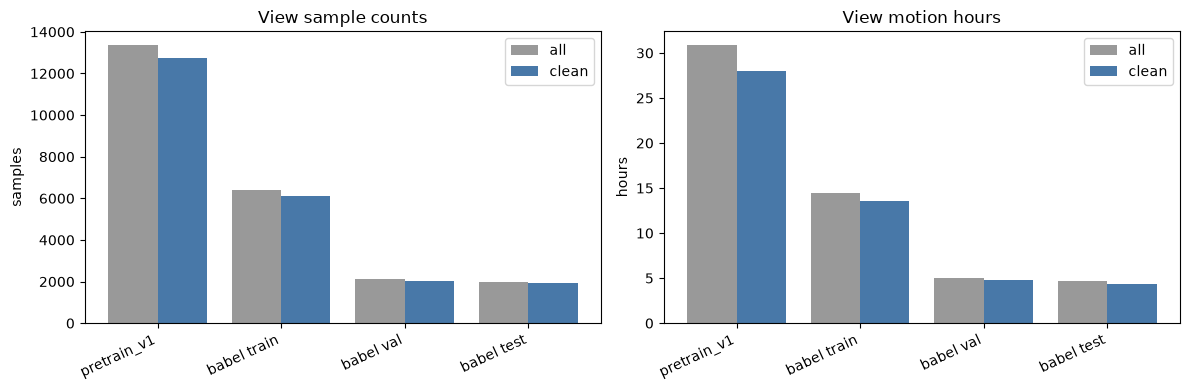

In [8]:
def split_ids(split_set: str, split: str) -> list[str]:
    return (
        splits
        .filter((pl.col("split_set") == split_set) & (pl.col("split") == split))
        .select("sample_id")
        .unique()
        .get_column("sample_id")
        .to_list()
    )

views = {
    "pretrain_v1": split_ids("pretrain_v1", "train"),
    "babel train": split_ids("babel_official", "train"),
    "babel val": split_ids("babel_official", "val"),
    "babel test": split_ids("babel_official", "test"),
}

rows = []
for name, ids in views.items():
    view = catalog.filter(pl.col("sample_id").is_in(ids))
    clean_view = view.filter(~pl.col("broken"))
    rows.append({
        "view": name,
        "samples": len(view),
        "clean_samples": len(clean_view),
        "hours": view["duration"].sum() / 3600,
        "clean_hours": clean_view["duration"].sum() / 3600,
    })

view_df = pl.DataFrame(rows)
print(view_df)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(view_df))

ax[0].bar(x - 0.2, view_df["samples"], width=0.4, label="all", color="#999999")
ax[0].bar(x + 0.2, view_df["clean_samples"], width=0.4, label="clean", color="#4878a8")
ax[0].set_xticks(x, view_df["view"], rotation=25, ha="right")
ax[0].set(title="View sample counts", ylabel="samples")
ax[0].legend()

ax[1].bar(x - 0.2, view_df["hours"], width=0.4, label="all", color="#999999")
ax[1].bar(x + 0.2, view_df["clean_hours"], width=0.4, label="clean", color="#4878a8")
ax[1].set_xticks(x, view_df["view"], rotation=25, ha="right")
ax[1].set(title="View motion hours", ylabel="hours")
ax[1].legend()

fig.tight_layout()

### Normalization stats


mean shape: (43, 5)
std shape:  (43, 5)
normalized channels: ['vel', 'acc', 'tau']
pass-through channels: ['sin', 'cos']


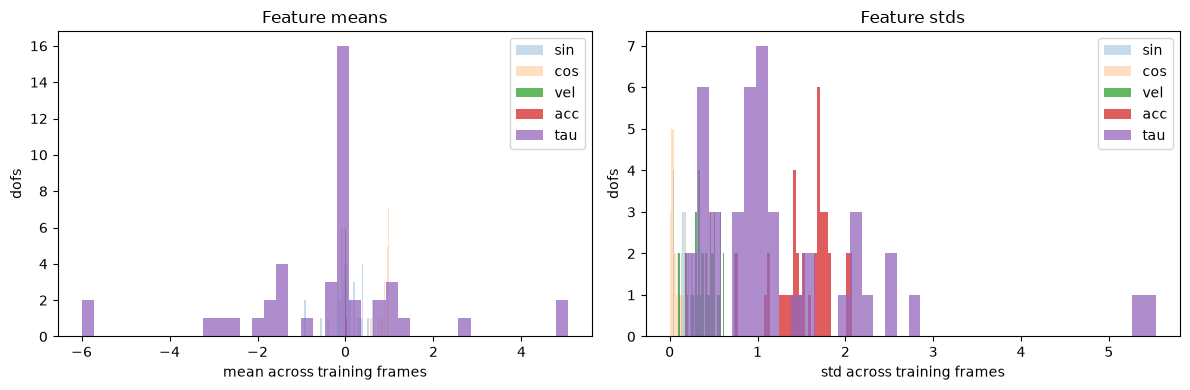

In [6]:
stats = t.load(NORMALIZATION_PATH, weights_only=True)
mean = stats["mean"].squeeze(0).numpy()
std = stats["std"].squeeze(0).numpy()

feature_names = list(REPRESENTATION.channels)
# sin/cos are bounded in [-1, 1] and encode circular geometry, so the representation
# passes them through untouched; the stats below only apply to the other three
passthrough = set(REPRESENTATION.indices("sin", "cos"))

print(f"mean shape: {mean.shape}")
print(f"std shape:  {std.shape}")
print("normalized channels:", [n for i, n in enumerate(feature_names) if i not in passthrough])
print("pass-through channels:", [n for i, n in enumerate(feature_names) if i in passthrough])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for channel, name in enumerate(feature_names):
    alpha = 0.25 if channel in passthrough else 0.75
    ax[0].hist(mean[:, channel], bins=40, alpha=alpha, label=name)
    ax[1].hist(std[:, channel], bins=40, alpha=alpha, label=name)

ax[0].set(title="Feature means", xlabel="mean across training frames", ylabel="dofs")
ax[1].set(title="Feature stds", xlabel="std across training frames", ylabel="dofs")
ax[0].legend()
ax[1].legend()

fig.tight_layout()


### Normalization effect on feature distributions


preview samples: 24
preview frames: 9,885


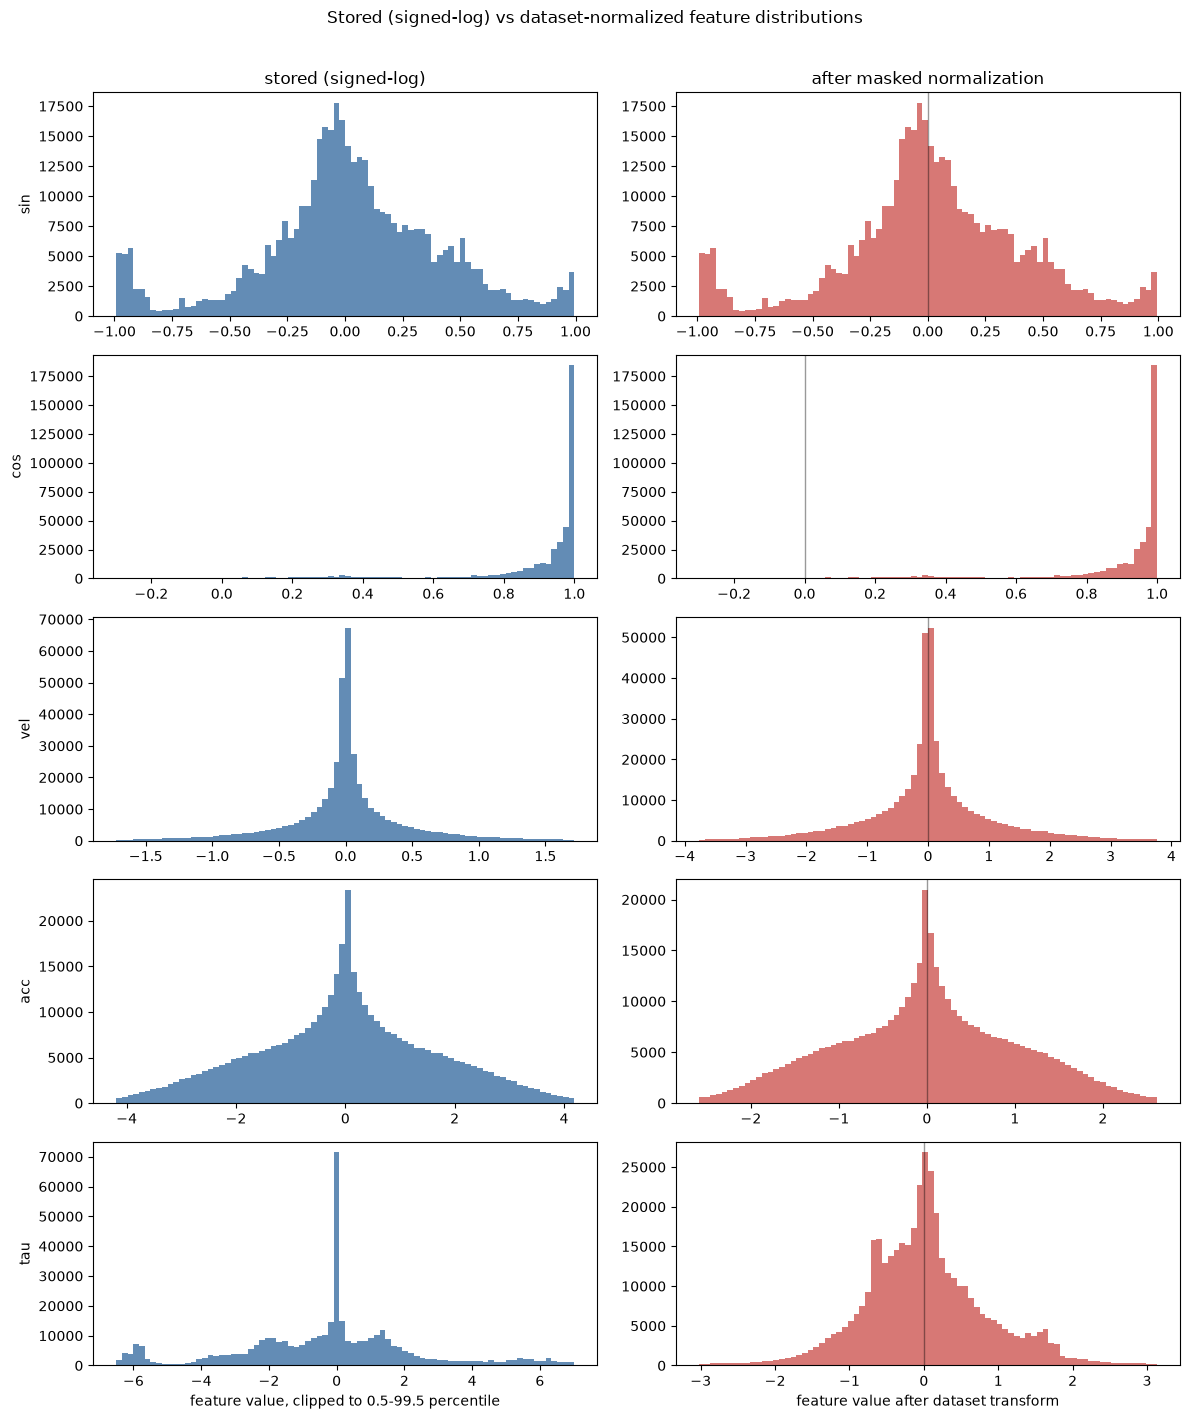

In [8]:
stats = t.load(NORMALIZATION_PATH, weights_only=True)
train_samples = build_motion_view(
    OUT,
    MotionViewSpec(
        split_set="pretrain_v1",
        split="train",
        source_datasets=("AMASS",),
        exclude_broken=True,
    )
)

preview_n = min(24, len(train_samples))
preview_samples = train_samples.sample(n=preview_n, seed=7) if preview_n else train_samples

stored_chunks = []
normalized_chunks = []
for row in preview_samples.iter_rows(named=True):
    payload = t.load(OUT / row["motion_path"], weights_only=True)
    features = payload["features"].float()
    normalized = REPRESENTATION.to_model(features, stats)

    step = max(1, features.shape[0] // 800)
    stored_chunks.append(features[::step])
    normalized_chunks.append(normalized[::step])

stored_preview = t.cat(stored_chunks, dim=0).numpy()
normalized_preview = t.cat(normalized_chunks, dim=0).numpy()

print(f"preview samples: {preview_n}")
print(f"preview frames: {stored_preview.shape[0]:,}")

fig, ax = plt.subplots(len(feature_names), 2, figsize=(12, 14))

for channel, name in enumerate(feature_names):
    stored_values = stored_preview[:, :, channel].reshape(-1)
    normalized_values = normalized_preview[:, :, channel].reshape(-1)

    stored_lo, stored_hi = np.percentile(stored_values, [0.5, 99.5])
    norm_lo, norm_hi = np.percentile(normalized_values, [0.5, 99.5])

    ax[channel, 0].hist(stored_values, bins=80, range=(stored_lo, stored_hi), color="#4878a8", alpha=0.85)
    ax[channel, 1].hist(normalized_values, bins=80, range=(norm_lo, norm_hi), color="#d1615d", alpha=0.85)

    ax[channel, 0].set_ylabel(name)
    ax[channel, 0].set_title("stored (signed-log)" if channel == 0 else "")
    ax[channel, 1].set_title("after masked normalization" if channel == 0 else "")
    ax[channel, 1].axvline(0, color="black", linewidth=1, alpha=0.4)

ax[-1, 0].set_xlabel("feature value, clipped to 0.5-99.5 percentile")
ax[-1, 1].set_xlabel("feature value after dataset transform")
fig.suptitle("Stored (signed-log) vs dataset-normalized feature distributions", y=1.01)
fig.tight_layout()


### Normalization summary on preview samples


In [ ]:
rows = []
for channel, name in enumerate(feature_names):
    stored_values = stored_preview[:, :, channel].reshape(-1)
    normalized_values = normalized_preview[:, :, channel].reshape(-1)
    rows.append({
        "feature": name,
        "stored_mean": stored_values.mean(),
        "stored_std": stored_values.std(),
        "after_mean": normalized_values.mean(),
        "after_std": normalized_values.std(),
        "after_p01": np.percentile(normalized_values, 1),
        "after_p99": np.percentile(normalized_values, 99),
    })

normalization_effect = pl.DataFrame(rows)
print(normalization_effect.with_columns(pl.all().exclude("feature").round(3)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(feature_names))

ax[0].bar(x - 0.2, normalization_effect["stored_mean"], width=0.4, label="stored", color="#4878a8")
ax[0].bar(x + 0.2, normalization_effect["after_mean"], width=0.4, label="after", color="#d1615d")
ax[0].axhline(0, color="black", linewidth=1, alpha=0.4)
ax[0].set_xticks(x, feature_names)
ax[0].set_title("Mean by feature channel")
ax[0].legend()

ax[1].bar(x - 0.2, normalization_effect["stored_std"], width=0.4, label="stored", color="#4878a8")
ax[1].bar(x + 0.2, normalization_effect["after_std"], width=0.4, label="after", color="#d1615d")
ax[1].axhline(1, color="black", linewidth=1, alpha=0.4)
ax[1].set_xticks(x, feature_names)
ax[1].set_title("Std by feature channel")
ax[1].legend()

fig.tight_layout()


### Normalization effect on one motion


In [ ]:
example = train_samples.sort("duration", descending=True).row(0, named=True)
payload = t.load(OUT / example["motion_path"], weights_only=True)
features = payload["features"].float()
normalized = REPRESENTATION.to_model(features, stats)
time = payload["time"].numpy()
dof_names = REPRESENTATION.dofs

fig, ax = plt.subplots(len(feature_names), 2, figsize=(14, 12), sharex=True)

for channel, name in enumerate(feature_names):
    dof = int(features[:, :, channel].std(dim=0).argmax())
    stored_series = features[:, dof, channel].numpy()
    normalized_series = normalized[:, dof, channel].numpy()

    ax[channel, 0].plot(time, stored_series, color="#4878a8", linewidth=1)
    ax[channel, 1].plot(time, normalized_series, color="#d1615d", linewidth=1)
    ax[channel, 1].axhline(0, color="black", linewidth=1, alpha=0.35)

    ax[channel, 0].set_ylabel(f"{name}\n{dof_names[dof]}")
    ax[channel, 0].set_title("stored (signed-log)" if channel == 0 else "")
    ax[channel, 1].set_title("after masked normalization" if channel == 0 else "")

ax[-1, 0].set_xlabel("time (s)")
ax[-1, 1].set_xlabel("time (s)")
fig.suptitle(f"{example['source_subset']} / {example['source_path']}", y=1.01)
fig.tight_layout()


## BABEL annotations

`annotations.parquet` holds the labels, `label_vocabulary.parquet` holds the 150-class action
set the BABEL benchmarks score. Both are separate from `splits.parquet`, because split
membership, what a sample *is*, and which answers a benchmark *admits* are three different
questions.

Each BABEL segment carries three parallel vocabularies — the annotator's free text (`raw`), its
normalized form (`proc`), and zero or more entries from the action taxonomy (`act_cat`) — stored
as separate rows under `ontology`. Sequence-level labels span the whole take; frame-level labels
carry their own start/end times and are absent for roughly 40% of sequences.


In [ ]:
annotations = load_annotations(OUT)
vocabulary = load_label_vocabulary(OUT, label_set="babel_action_150")

print(f"{len(annotations):,} annotation rows over {annotations['sample_id'].n_unique():,} samples")
print(f"{len(vocabulary)} action classes, index {vocabulary['label_index'].min()}..{vocabulary['label_index'].max()}")
print(annotations.group_by("label_type", "ontology").len().sort("label_type", "ontology"))

# label coverage per split. BABEL publishes no labels for test, so 0 there is expected, not a bug.
rows = []
for split in ("train", "val", "test"):
    ids = split_ids("babel_official", split)
    labelled = annotations.filter(pl.col("sample_id").is_in(ids))
    rows.append({
        "split": split,
        "samples": len(ids),
        "labelled": labelled["sample_id"].n_unique(),
        "annotations": len(labelled),
    })
coverage_df = pl.DataFrame(rows).with_columns(
    (100 * pl.col("labelled") / pl.col("samples")).round(1).alias("labelled_pct")
)
print(coverage_df)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

counts = annotations.group_by("label_type", "ontology").len().sort("ontology", "label_type")
x = np.arange(counts["ontology"].n_unique())
for offset, label_type, color in [(-0.2, "sequence", "#4878a8"), (0.2, "frame", "#6acc64")]:
    sub = counts.filter(pl.col("label_type") == label_type).sort("ontology")
    ax[0].bar(x + offset, sub["len"], width=0.4, label=label_type, color=color)
ax[0].set_xticks(x, sorted(counts["ontology"].unique()))
ax[0].set(title="Rows by ontology", ylabel="annotation rows")
ax[0].legend()

xs = np.arange(len(coverage_df))
ax[1].bar(xs - 0.2, coverage_df["samples"], width=0.4, label="in split", color="#999999")
ax[1].bar(xs + 0.2, coverage_df["labelled"], width=0.4, label="labelled", color="#4878a8")
ax[1].set_xticks(xs, coverage_df["split"])
ax[1].set(title="Label coverage by BABEL split", ylabel="samples")
ax[1].legend()

per_sample = annotations.group_by("sample_id").len()["len"].to_numpy()
ax[2].hist(per_sample, bins=60, color="#d1615d")
ax[2].set(xlabel="annotation rows per sample", ylabel="samples",
          title=f"median {int(np.median(per_sample))} rows/sample")

fig.tight_layout()


### Action categories vs the benchmark vocabulary

The corpus contains more distinct `act_cat` values than the 150-class benchmark admits. The
extra ones are a long tail that downstream tasks drop rather than treat as additional classes,
so what matters is how much data survives that filter — and how skewed what remains is.


act_cat rows: 65,556 | in vocabulary: 52,220 (79.7%)
distinct labels: 243 | in vocabulary: 150 | dropped: 93
samples keeping >=1 in-vocabulary label: 8,422 of 8,492

top class (transition) is 19.1% of all act_cat rows
top 10 classes cover 58.0%


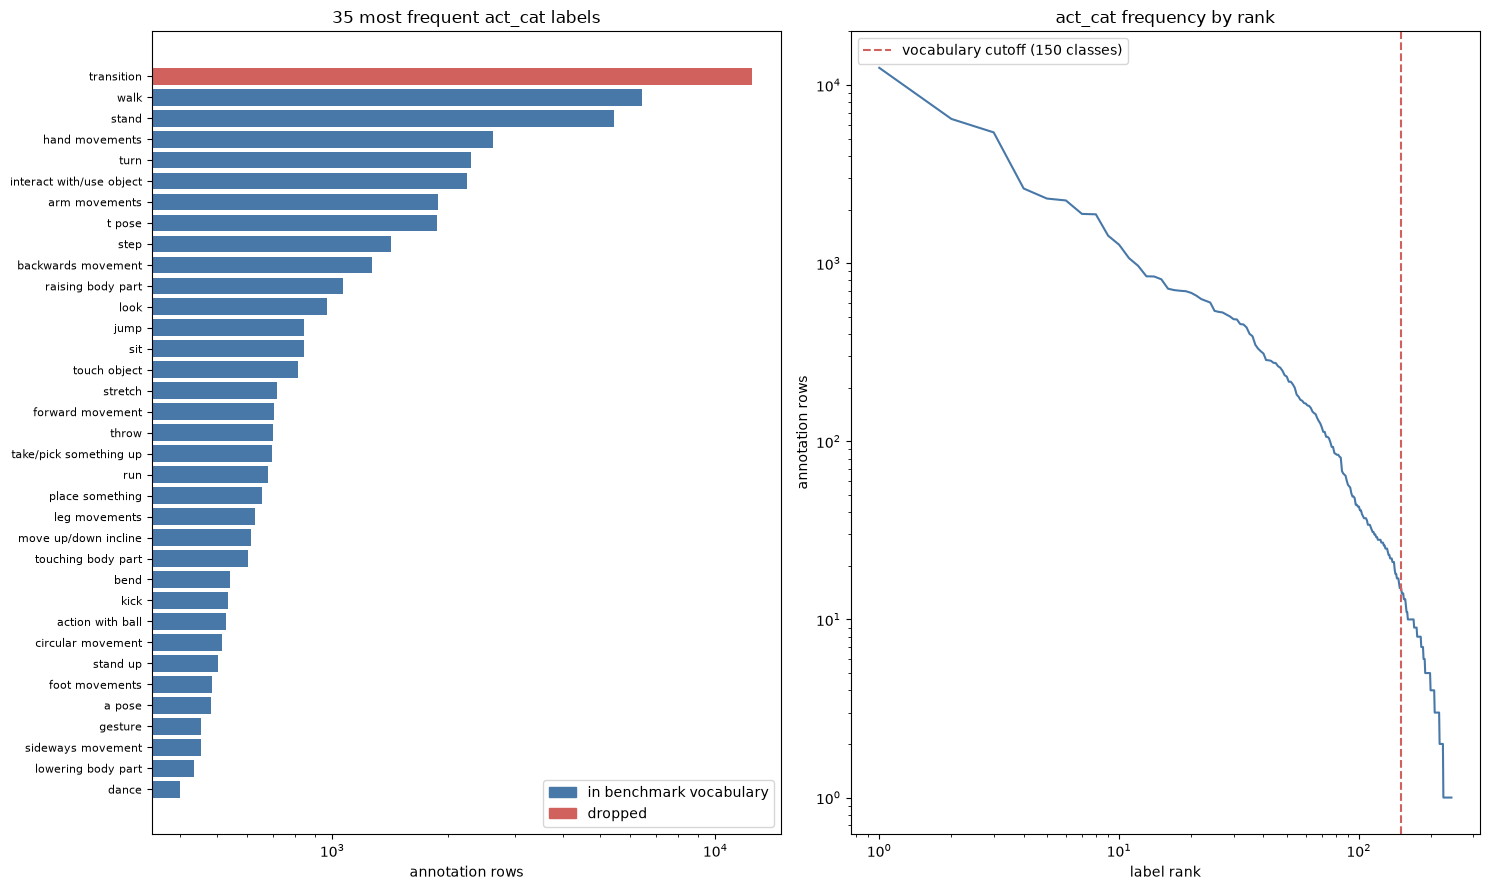

In [10]:
act_cat = (
    annotations
    .filter(pl.col("ontology") == "act_cat")
    .join(vocabulary.select("label", "label_index"), on="label", how="left")
    .with_columns(pl.col("label_index").is_not_null().alias("in_vocabulary"))
)

in_vocab = act_cat.filter("in_vocabulary")
print(f"act_cat rows: {len(act_cat):,} | in vocabulary: {len(in_vocab):,} "
      f"({100 * len(in_vocab) / len(act_cat):.1f}%)")
print(f"distinct labels: {act_cat['label'].n_unique()} | in vocabulary: {in_vocab['label'].n_unique()} "
      f"| dropped: {act_cat.filter(~pl.col('in_vocabulary'))['label'].n_unique()}")
print(f"samples keeping >=1 in-vocabulary label: {in_vocab['sample_id'].n_unique():,} "
      f"of {act_cat['sample_id'].n_unique():,}")

by_label = act_cat.group_by("label", "in_vocabulary").len().sort("len", descending=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 9))

top = by_label.head(35).sort("len")
colors = ["#4878a8" if v else "#d1615d" for v in top["in_vocabulary"]]
ax[0].barh(np.arange(len(top)), top["len"], color=colors)
ax[0].set_yticks(np.arange(len(top)), top["label"], fontsize=8)
ax[0].set(xlabel="annotation rows", title="35 most frequent act_cat labels")
ax[0].set_xscale("log")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ("#4878a8", "#d1615d")]
ax[0].legend(handles, ["in benchmark vocabulary", "dropped"], loc="lower right")

# frequency rank curve: how top-heavy the label distribution is
ranked = by_label.sort("len", descending=True)
ax[1].plot(np.arange(1, len(ranked) + 1), ranked["len"], color="#4878a8")
ax[1].axvline(len(vocabulary), color="#d1615d", linestyle="--",
              label=f"vocabulary cutoff ({len(vocabulary)} classes)")
ax[1].set(xscale="log", yscale="log", xlabel="label rank", ylabel="annotation rows",
          title="act_cat frequency by rank")
ax[1].legend()

fig.tight_layout()

share = ranked["len"].to_numpy()
print(f"\ntop class ({ranked['label'][0]}) is {100 * share[0] / share.sum():.1f}% of all act_cat rows")
print(f"top 10 classes cover {100 * share[:10].sum() / share.sum():.1f}%")


### Frame segments in time

Frame-level labels are what a temporal probe would actually train on, so their spans matter:
how long a labelled segment lasts decides what window size can contain one, and how much of each
motion is covered decides how much of the corpus a supervised task can use at all.


41,554 frame segments over 5,039 samples
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 41554.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 1.761286 │
│ std        ┆ 2.941878 │
│ min        ┆ -2.571   │
│ 25%        ┆ 0.56     │
│ 50%        ┆ 1.028    │
│ 75%        ┆ 1.834    │
│ max        ┆ 57.5     │
└────────────┴──────────┘

segments shorter than the window: 92.4%
median coverage: 101% of motion duration
above 100% means overlapping segments, i.e. concurrent actions on the same frames


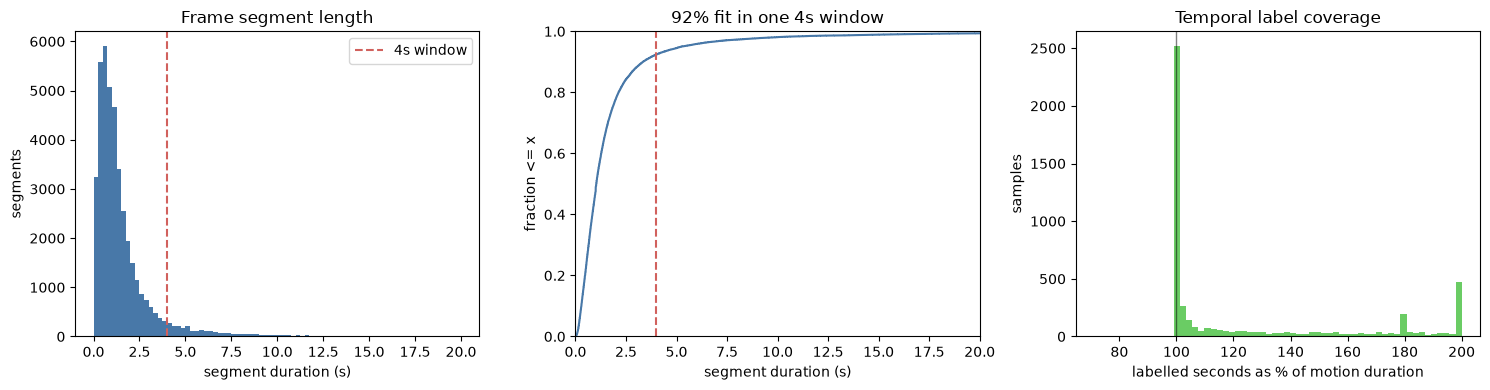

In [11]:
WINDOW_SECONDS = 4.0   # the training window this corpus is sampled into

# one row per distinct segment: act_cat duplicates a segment across its categories
segments = (
    annotations
    .filter((pl.col("label_type") == "frame") & (pl.col("ontology") == "proc"))
    .with_columns((pl.col("end_t") - pl.col("start_t")).alias("seconds"))
)
print(f"{len(segments):,} frame segments over {segments['sample_id'].n_unique():,} samples")
print(segments["seconds"].describe())

covered = (
    segments
    .group_by("sample_id")
    .agg(pl.col("seconds").sum().alias("labelled_seconds"))
    .join(catalog.select("sample_id", "duration"), on="sample_id", how="inner")
    .with_columns((100 * pl.col("labelled_seconds") / pl.col("duration")).alias("covered_pct"))
)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

seconds = segments["seconds"].to_numpy()
ax[0].hist(seconds, bins=80, range=(0, 20), color="#4878a8")
ax[0].axvline(WINDOW_SECONDS, color="#d1615d", linestyle="--", label=f"{WINDOW_SECONDS:g}s window")
ax[0].set(xlabel="segment duration (s)", ylabel="segments", title="Frame segment length")
ax[0].legend()

ax[1].ecdf(seconds, color="#4878a8")
ax[1].axvline(WINDOW_SECONDS, color="#d1615d", linestyle="--")
ax[1].set(xlabel="segment duration (s)", ylabel="fraction <= x", xlim=(0, 20),
          title=f"{100 * (seconds <= WINDOW_SECONDS).mean():.0f}% fit in one {WINDOW_SECONDS:g}s window")

ax[2].hist(covered["covered_pct"].to_numpy().clip(0, 200), bins=60, color="#6acc64")
ax[2].axvline(100, color="black", linewidth=1, alpha=0.5)
ax[2].set(xlabel="labelled seconds as % of motion duration", ylabel="samples",
          title="Temporal label coverage")

fig.tight_layout()

print(f"\nsegments shorter than the window: {100 * (seconds <= WINDOW_SECONDS).mean():.1f}%")
print(f"median coverage: {covered['covered_pct'].median():.0f}% of motion duration")
print("above 100% means overlapping segments, i.e. concurrent actions on the same frames")
